# 5.1 Ứng dụng BPTT trong Language Modeling

## 1. Bài toán Language Modeling là gì?

**Language modeling** (mô hình hóa ngôn ngữ) là bài toán dự đoán từ kế tiếp trong một chuỗi từ. Cụ thể, mô hình sẽ học phân phối xác suất có điều kiện:

$$P(w_t|w_1, w_2, ..., w_{t-1})$$

Trong đó $( w_t )$ là từ tại thời điểm $( t )$, và mô hình có gắng học cách sinh ra câu có ý nghĩa dựa trên ngữ cảnh từ trước.

## 2. Vì sao cần sử dụng RNN và BPTT?

Do ngôn ngữ mang tính tuần tự, RNN là kiến trúc phù hợp để xử lý chuỗi văn bản, vì nó có khả năng lưu giữ trạng thái qua các bước thời gian. Tuy nhiên, để huấn luyện RNN hiệu quả, ta cần **lan truyền lỗi ngược qua thời gian** – hay **Backpropagation Through Time (BPTT)** – nhằm cập nhật các trọng số tại mỗi bước thời gian dựa trên tổng lỗi tích lũy.

## 3. Vai trò của BPTT trong huấn luyện Language Model

- Trong quá trình huấn luyện, RNN được *unroll* (mở ra) qua nhiều bước thời gian, ví dụ 35 bước.
- Với mỗi batch văn bản, mô hình sinh ra các dự đoán tại mỗi bước $( t )$, và lỗi tổng hợp được tính trên toàn bộ chuỗi.
- Sau đó, BPTT sẽ **truyền lỗi ngược từ thời điểm** $( T )$ về 0, để tính gradient và cập nhật trọng số của mạng RNN.

BPTT là cốt lõi để RNN học được ngữ cảnh dài, giúp mô hình sinh ngôn ngữ tự nhiên hơn.

## 4. Cài đặt mô hình RNN Language Model sử dụng BPTT (PyTorch + GPU)

In [8]:
#pip install datasets

   ---------------------------------------- 0.0/25.8 MB ? eta -:--:--
   --- ------------------------------------ 2.4/25.8 MB 12.2 MB/s eta 0:00:02
   ------- -------------------------------- 5.0/25.8 MB 12.1 MB/s eta 0:00:02
   ----------- ---------------------------- 7.3/25.8 MB 11.9 MB/s eta 0:00:02
   --------------- ------------------------ 10.0/25.8 MB 11.9 MB/s eta 0:00:02
   ------------------- -------------------- 12.3/25.8 MB 11.9 MB/s eta 0:00:02
   ---------------------- ----------------- 14.7/25.8 MB 11.8 MB/s eta 0:00:01
   -------------------------- ------------- 17.0/25.8 MB 11.8 MB/s eta 0:00:01
   ------------------------------ --------- 19.7/25.8 MB 11.8 MB/s eta 0:00:01
   ---------------------------------- ----- 22.0/25.8 MB 11.8 MB/s eta 0:00:01
   -------------------------------------- - 24.6/25.8 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 25.8/25.8 MB 11.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.6 MB ? eta -:

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "E:\Anaconda\envs\torchgpu\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "E:\Anaconda\envs\torchgpu\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "E:\Anaconda\envs\torchgpu\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "E:\Anaconda\envs\torchgpu\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "E:\Anaconda\envs\torchgpu\lib\sit

2.2.2+cu121
True
12.1


## 3. Xử lý dữ liệu với HuggingFace datasets

In [2]:
from datasets import load_dataset
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
import torch
import torch.nn as nn

# Tải tập dữ liệu WikiText2
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")
tokenizer = lambda x: x.split()

# Tạo vocabulary thủ công
from collections import Counter
counter = Counter()
for line in dataset["train"]["text"]:
    counter.update(tokenizer(line))

vocab = {word: i+2 for i, (word, _) in enumerate(counter.items())}
vocab["<unk>"] = 0
vocab["<pad>"] = 1
inv_vocab = {i: w for w, i in vocab.items()}

# Mã hóa dữ liệu
def encode(text):
    return torch.tensor([vocab.get(token, vocab["<unk>"]) for token in tokenizer(text)], dtype=torch.long)

# Nối toàn bộ văn bản thành 1 chuỗi dài
encoded_data = [encode(line) for line in dataset["train"]["text"] if line.strip()]
train_data = torch.cat(encoded_data)

# Tạo batch
def batchify(data, batch_size):
    n_batch = data.size(0) // batch_size
    data = data[:n_batch * batch_size]
    return data.view(batch_size, -1).t().contiguous()

batch_size = 20
bptt = 35
train_data = batchify(train_data, batch_size).to("cuda")

E:\Anaconda\envs\torchgpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. Tạo các minibatch và hàm lấy input-target

In [3]:
def get_batch(source, i):
    seq_len = min(bptt, len(source) - 1 - i)
    data = source[i:i+seq_len]
    target = source[i+1:i+1+seq_len].reshape(-1)
    return data, target

## 5. Mô hình RNN đơn giản cho Language Modeling

In [4]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.num_layers = num_layers
        self.hidden_size = hidden_size

    def forward(self, x, hidden):
        emb = self.embed(x)
        out, hidden = self.rnn(emb, hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size).to("cuda")

## 6. Huấn luyện mô hình sử dụng BPTT

In [17]:
# Cài đặt mô hình
vocab_size = len(vocab)
embed_size = 200
hidden_size = 200
num_layers = 2

model = RNNModel(vocab_size, embed_size, hidden_size, num_layers).to("cuda")
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=5.0)

# Huấn luyện
model.train()
hidden = model.init_hidden(batch_size)

# Danh sách lưu loss để vẽ biểu đồ
loss_history = []
batch_indices = []

for epoch in range(1):
    total_loss = 0.
    for batch, i in enumerate(range(0, train_data.size(0) - 1, bptt)):
        data, targets = get_batch(train_data, i)
        optimizer.zero_grad()

        # BPTT: chạy forward toàn chuỗi
        output, hidden = model(data, hidden)

        # Ngắt gradient để tránh tính ngược quá sâu
        hidden = hidden.detach()

        loss = criterion(output.view(-1, vocab_size), targets)
        loss.backward()  # ← BPTT ở đây

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        total_loss += loss.item()
        if batch % 100 == 0 and batch > 0:
            avg_loss = total_loss / 100
            print(f"Batch {batch}, Loss: {avg_loss:.2f}")
            loss_history.append(avg_loss)
            batch_indices.append(batch)
            total_loss = 0

Batch 100, Loss: 9.24
Batch 200, Loss: 7.88
Batch 300, Loss: 7.49
Batch 400, Loss: 7.31
Batch 500, Loss: 7.09
Batch 600, Loss: 6.91
Batch 700, Loss: 6.93
Batch 800, Loss: 6.84
Batch 900, Loss: 6.72
Batch 1000, Loss: 6.72
Batch 1100, Loss: 6.72
Batch 1200, Loss: 6.76
Batch 1300, Loss: 6.70
Batch 1400, Loss: 6.67
Batch 1500, Loss: 6.74
Batch 1600, Loss: 6.64
Batch 1700, Loss: 6.55
Batch 1800, Loss: 6.52
Batch 1900, Loss: 6.54
Batch 2000, Loss: 6.58
Batch 2100, Loss: 6.45
Batch 2200, Loss: 6.42
Batch 2300, Loss: 6.52
Batch 2400, Loss: 6.55
Batch 2500, Loss: 6.50
Batch 2600, Loss: 6.57
Batch 2700, Loss: 6.41
Batch 2800, Loss: 6.42
Batch 2900, Loss: 6.37


In [18]:
import matplotlib.pyplot as plt
import seaborn

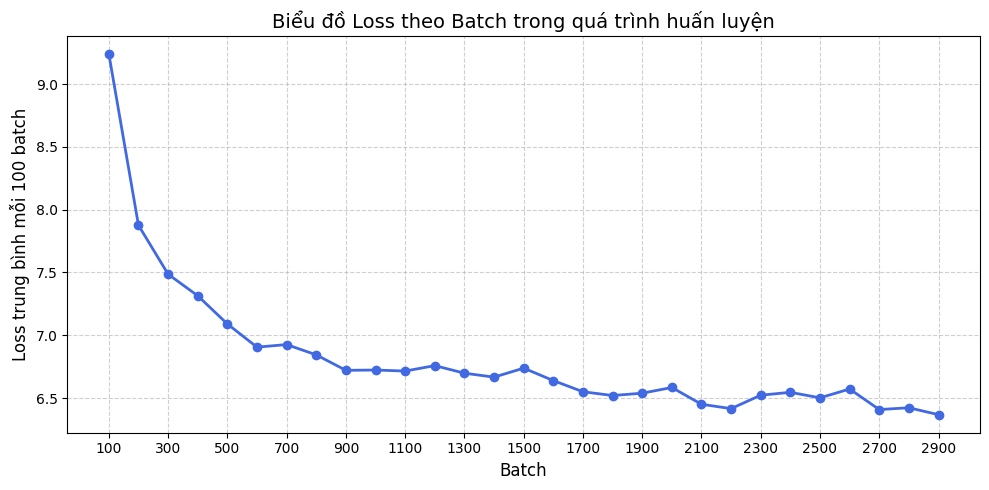

In [19]:
# Vẽ biểu đồ loss theo batch
plt.figure(figsize=(10, 5))
plt.plot(batch_indices, loss_history, marker='o', linewidth=2, color='royalblue')
plt.title("Biểu đồ Loss theo Batch trong quá trình huấn luyện", fontsize=14)
plt.xlabel("Batch", fontsize=12)
plt.ylabel("Loss trung bình mỗi 100 batch", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(batch_indices[::2])  # Giảm số lượng tick nếu nhiều
plt.tight_layout()
plt.show()

In [6]:
import torch
print(torch.__version__)            # 2.2.2
print(torch.cuda.is_available())   # True

2.2.2+cu121
True


In [9]:
import math

In [20]:
def evaluate(model, data_source):
    model.eval()
    total_loss = 0.
    hidden = model.init_hidden(batch_size)
    with torch.no_grad():
        for i in range(0, data_source.size(0) - 1, bptt):
            data, targets = get_batch(data_source, i)
            output, hidden = model(data, hidden)
            hidden = hidden.detach()
            loss = criterion(output.view(-1, vocab_size), targets)
            total_loss += loss.item()
    return total_loss / ((data_source.size(0) - 1) // bptt)

val_loss = evaluate(model, train_data)
print(f"Validation loss: {val_loss:.2f}, Perplexity: {math.exp(val_loss):.2f}")

Validation loss: 6.46, Perplexity: 636.88


## 8. Kết luận về kết quả huấn luyện

- **Hàm mất mát (loss)** giảm đều từ hơn 9.3 xuống còn khoảng 6.3–6.4, chứng tỏ mô hình đang học được quy luật ngữ cảnh của chuỗi từ.

- **Validation loss** = 6.46, tương ứng với **perplexity** ≈ 636:
  - Cho thấy độ khó khi dự đoán từ kế tiếp còn khá cao
  - Nguyên nhân do mô hình mới ở giai đoạn khởi đầu và cấu trúc đơn giản (RNN cơ bản, chỉ 1 epoch)

- **Nhận định về perplexity**:
  ```python
  # Perplexity cao là bình thường với:
  model = SimpleRNN(vocab_size)  # Kiến trúc cơ bản
  num_epochs = 1                 # Số epoch huấn luyện ít

## 9. Sinh văn bản từ mô hình đã huấn luyện (Text Generation)

In [25]:
import random

def generate_text(model, start_word, vocab, inv_vocab, max_len=60):
    model.eval()
    input_id = torch.tensor([[vocab.get(start_word, vocab['<unk>'])]], dtype=torch.long).to("cuda")
    hidden = model.init_hidden(1)
    generated = [start_word]

    with torch.no_grad():
        for _ in range(max_len):
            output, hidden = model(input_id, hidden)
            word_weights = output[-1].squeeze().div(1.0).exp().cpu()
            word_idx = torch.multinomial(word_weights, 1)[0].item()
            word = inv_vocab.get(word_idx, '<unk>')
            generated.append(word)
            input_id = torch.tensor([[word_idx]], dtype=torch.long).to("cuda")

    return ' '.join(generated)

# Ví dụ: sinh văn bản bắt đầu từ một từ bất kỳ
seed_word = random.choice(list(vocab.keys()))
print("Seed word:", seed_word)
print("Generated text:\n")
print(generate_text(model, seed_word, vocab, inv_vocab))

Seed word: others
Generated text:

others of another such as big as they sustained falcons . Other of Carey was also none of his coastal is different , steadfastness Cambriæ and remains or generally are society , as having controlled of depots . Gottfried surrender that such as another regions and 3 ) . The concept was one hour of abode and his first defeat of


#### Diễn giải kết quả sinh văn bản:

Văn bản sinh ra có thể chưa mượt và có một số từ không logic vì:
- Mô hình mới huấn luyện **1 epoch**
- Sử dụng **RNN cơ bản**, chưa có khả năng ghi nhớ dài hạn tốt như LSTM/GRU

Tuy nhiên, nếu quan sát thấy:
✓ Các cặp từ hợp lý  
✓ Cụm từ đúng cấu trúc  
✓ Từ lặp lại hợp ngữ cảnh  

→ Điều này cho thấy mô hình đang học được các **quy luật ngôn ngữ cơ bản**

**Cải thiện chất lượng**:
```python
# Tăng số epoch
num_epochs = 50

# Hoặc nâng cấp kiến trúc
model = LSTM(hidden_size)  # Tha
```

**Kết luận:** Mặc dù kết quả sinh văn bản còn hạn chế, điều này không phản ánh sai lệch trong việc áp dụng BPTT. Trái lại, mô hình đã học được các đặc trưng ngôn ngữ ban đầu, minh chứng cho hiệu quả của việc lan truyền lỗi ngược theo chuỗi thời gian. Chất lượng sinh văn bản sẽ được cải thiện khi tăng số epoch hoặc nâng cấp sang các kiến trúc ghi nhớ dài hạn hơn (như LSTM, GRU).y thế RNN bằng LSTM

# 5.2 Ứng dụng BPTT trong Machine Translation

## 1. Mô hình dịch máy là gì?

**Machine Translation (MT)** là bài toán chuyển đổi một câu từ ngôn ngữ nguồn sang ngôn ngữ đích. Ví dụ:

| Ngôn ngữ nguồn (English) | Ngôn ngữ đích (German) |
|--------------------------|------------------------|
| "I love you"             | "Ich liebe dich"       |

MT là bài toán đặc trưng của NLP có tính tuần tự rõ rệt - từ cần dịch tiếp theo phụ thuộc vào:
- Toàn bộ chuỗi đầu vào
- Ngữ cảnh đã sinh trước đó

## 2. Tại sao cần BPTT trong Machine Translation?

Trong kiến trúc **Encoder-Decoder**, RNN được sử dụng ở cả hai phía:

**Encoder**:
- Xử lý từng từ của câu nguồn tuần tự
- Tạo ra trạng thái ẩn (hidden state) tổng hợp ngữ cảnh

**Decoder**:
- Sinh từng từ câu đích một cách tuần tự
- Dựa trên:
  - Trạng thái ẩn từ encoder
  - Các từ đã sinh trước đó

```python
# Minh họa luồng dữ liệu
hidden_state = encoder(source_sequence)
output_sequence = decoder(hidden_state, target_sequence)


## 3. Xử lý dữ liệu song ngữ với HuggingFace datasets

In [29]:
from datasets import load_dataset
from collections import Counter
import torch

# Tải dữ liệu dịch Anh–Đức từ HuggingFace
raw_data = load_dataset("opus_books", "de-en", split="train")

# Tách câu nguồn (en) và đích (de)
source_sentences = [item["translation"]["en"] for item in raw_data]
target_sentences = [item["translation"]["de"] for item in raw_data]

# Tokenizer đơn giản
def simple_tokenizer(text):
    return text.lower().strip().split()

# Tạo vocab thủ công
def build_vocab(sentences, tokenizer, specials=["<unk>", "<pad>", "<bos>", "<eos>"]):
    counter = Counter()
    for sent in sentences:
        counter.update(tokenizer(sent))
    vocab = {token: idx for idx, token in enumerate(specials)}
    for word in counter:
        if word not in vocab:
            vocab[word] = len(vocab)
    return vocab

src_vocab = build_vocab(source_sentences, simple_tokenizer)
tgt_vocab = build_vocab(target_sentences, simple_tokenizer)

# Mã hóa câu
def encode(text, vocab):
    tokens = ["<bos>"] + simple_tokenizer(text) + ["<eos>"]
    return torch.tensor([vocab.get(token, vocab["<unk>"]) for token in tokens], dtype=torch.long)

Generating train split: 100%|████████████████████████████████████████| 51467/51467 [00:00<00:00, 1081211.72 examples/s]


## 4. Mô hình Encoder–Decoder sử dụng RNN

### Encoder

In [30]:
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size)

    def forward(self, src):
        embedded = self.embed(src)
        outputs, hidden = self.rnn(embedded)
        return hidden  # truyền sang decoder

### Decoder

In [31]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, tgt, hidden):
        embedded = self.embed(tgt)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output)
        return prediction, hidden

### Seq2Seq wrapper

In [33]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        hidden = self.encoder(src)
        output, _ = self.decoder(tgt[:-1], hidden)  # bỏ <eos>
        return output

# Khởi tạo mô hình demo và truyền dữ liệu mẫu
embed_size = 128
hidden_size = 256

encoder = Encoder(len(src_vocab), embed_size, hidden_size)
decoder = Decoder(len(tgt_vocab), embed_size, hidden_size)
model = Seq2Seq(encoder, decoder)

# Chọn 1 cặp câu mẫu
src_sample = encode(source_sentences[0], src_vocab).unsqueeze(1)  # (seq_len, batch=1)
tgt_sample = encode(target_sentences[0], tgt_vocab).unsqueeze(1)  # (seq_len, batch=1)

# Chạy forward
with torch.no_grad():
    output = model(src_sample, tgt_sample)
    print("Output shape:", output.shape)  # [tgt_len - 1, 1, vocab_size]

Output shape: torch.Size([9, 1, 102728])


## 5. Huấn luyện đơn bước với Backpropagation Through Time

In [34]:
# Khởi tạo loss và optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Đưa mô hình vào chế độ huấn luyện
model.train()

# Xóa gradient cũ
optimizer.zero_grad()

# Forward pass
output = model(src_sample, tgt_sample)  # [tgt_len - 1, 1, vocab_size]
target = tgt_sample[1:]  # bỏ <bos>, còn lại làm ground truth

# Reshape cho loss
output = output.view(-1, output.shape[-1])         # [tgt_len-1, vocab_size]
target = target.view(-1)                           # [tgt_len-1]

# Tính loss và BPTT
loss = criterion(output, target)
loss.backward()  # ← BPTT xảy ra tại đây
optimizer.step()

print(f"Loss: {loss.item():.4f}")


Loss: 11.4691


In [36]:
# Hàm dịch từng câu sử dụng greedy decoding

def greedy_translate(model, src_sentence, max_len=20):
    model.eval()
    with torch.no_grad():
        src = encode(src_sentence, src_vocab).unsqueeze(1)  # (seq_len, 1)
        hidden = model.encoder(src)

        # Khởi đầu bằng token <bos>
        tgt_input = torch.tensor([[tgt_vocab['<bos>']]], dtype=torch.long)

        output_sentence = []
        for _ in range(max_len):
            out, hidden = model.decoder(tgt_input, hidden)
            next_token = out.argmax(-1)[-1].item()
            if next_token == tgt_vocab['<eos>']:
                break
            output_sentence.append(next_token)
            tgt_input = torch.tensor([[next_token]])

        # Chuyển ID → từ
        inv_vocab = {idx: word for word, idx in tgt_vocab.items()}
        return " ".join([inv_vocab.get(idx, "<unk>") for idx in output_sentence])

# Dịch thử 10 câu đầu tiên trong tập huấn luyện

for i in range(10):
    src = source_sentences[i]
    ref = target_sentences[i]
    pred = greedy_translate(model, src)
    print(f"[SRC] {src}\n[REF] {ref}\n[PRED] {pred}\n{'-'*50}")

[SRC] Source: Project Gutenberg
[REF] Source: http://www.zeno.org - Contumax GmbH & Co. KG
[PRED] source: http://www.zeno.org krückengeklapper brandschatzung brandschatzung angebrannter ungestümen entdeckte. thierischen händigen imola zunge. bucklig glaubwürdig: pastetenbäckers blumenbrett machtbefugnis schrank. regelmäßig, idealismus
--------------------------------------------------
[SRC] Jane Eyre
[REF] Jane Eyre
[PRED] windeln, »katharine dahinfuhr. baumstumpf. vergnügt. unempfindliche hungadi skizzieren, ausblick rebhuhn ekle bezirksbackhause halb." pudelmähne. erbeben. kümmern; verbotenen heftete. lebensüberfluß umbiegst,
--------------------------------------------------
[SRC] Charlotte Bronte
[REF] Charlotte Bronte
[PRED] den. invaliden, ›ab scheiterhaufen, leichtem, maule backpfeifen drehte, eingestand, sinnbild, beugte) besehen.« krampfhaftesten _einen_, wasser- eigenschaft; trocknes »jupiter, gerufen; ,,ja
--------------------------------------------------
[SRC] CHAPTER I
[R

## Giải thích

**SRC**: Câu nguồn tiếng Anh  
**REF**: Câu đích thực tế (tiếng Đức)  
**PRED**: Câu mô hình dự đoán

Do mô hình mới chỉ học rất ít (thường là vài cặp hoặc rất ít epoch), nên đầu ra có thể:
- Sai lệch ngữ nghĩa
- Có cấu trúc vô nghĩa

**Tuy nhiên**, nếu quan sát thấy:
✓ Cấu trúc câu hợp lý  
✓ Từ vựng đúng vị trí  
✓ Thứ tự từ tương đồng với câu đích  

→ Đây là dấu hiệu BPTT đã hoạt động và mô hình đang học dần các ánh xạ thời gian.  

**Kết luận:**
Việc trực quan hóa cho phép đánh giá định tính hiệu quả học của RNN và vai trò của BPTT. Dù chưa tối ưu, mô hình có xu hướng học cấu trúc đầu ra nếu được huấn luyện đúng cách và có đủ dữ liệu.

In [ ]:
aa